In [26]:
# Setup for Google Colab (optional)
import sys
if 'google.colab' in sys.modules:
    print("Running in Google Colab")
    # Install required packages
    !pip install -q py4DSTEM hyperspy scikit-image matplotlib numpy scipy
    
    # Clone the repository to access data
    !git clone -q https://github.com/NU-MSE-LECTURES/465-WINTER2026.git
    import os
    os.chdir('/content/465-WINTER2026')
    
    # Set up file handling
    from google.colab import files
    print("Colab setup complete!")
else:
    print("Running in local environment")

Running in local environment


<a href="https://colab.research.google.com/github/NU-MSE-LECTURES/465-WINTER2026/blob/main/Week_02/assignments/assignment_02_setup.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Assignment 02: 4D-STEM Foundations

Complete this assignment to demonstrate your understanding of 4D-STEM data analysis and calibration.


In [27]:
# Colab setup
try:
    import google.colab
    IN_COLAB = True
    print("Running in Google Colab. Installing requirements...")
    !pip install hyperspy ase py4DSTEM
    !git clone https://github.com/NU-MSE-LECTURES/465_Computational_Microscopy_2026.git
    print("Setup complete.")
except ImportError:
    IN_COLAB = False
    print("Not running in Google Colab.")

Not running in Google Colab.


## Task 1: Distinguish Navigation vs. Signal Axes

In your notebook, define the "Navigation Axes" (where the measurement is made, e.g., x, y scan positions).

Define the "Signal Axes" (what is measured at each point, e.g., an EELS spectrum or a 2D diffraction pattern).

Use signal.axes manager to print and verify the dimensionality of a 4D-STEM dataset (expected: 2 Navigation, 2 Signal).

In [28]:
def print_axes_info(dataset):
    am = dataset.data.axes_manager
    print(am)
    print("Navigation dims:", am.navigation_dimension)
    print("Signal dims:", am.signal_dimension)

## Task 2: Load and Calibrate 4D-STEM Data

Use py4DSTEM.io.read to load a 4D-STEM dataset (e.g., .dm4 or .h5).

**Note:** The dataset Si-SiGe.dm4 should be available in the raw_data folder.

Set the scan step size (real space calibration) using dataset.set_scan_step_size().

Perform Center of Mass (CoM) correction using dataset.get_diffraction_shifts() to center the unscattered beam.

In [29]:
from pathlib import Path
import numpy as np
import py4DSTEM

DATA_PATH = Path.home() / "Desktop" / "465" / "Si-SiGe.dm4"
dataset = py4DSTEM.import_file(str(DATA_PATH))

SCAN_STEP_NM = 1.0

arr = np.asarray(dataset.data)
Ny_scan, Nx_scan, Ny_dp, Nx_dp = arr.shape
target_cy, target_cx = (Ny_dp - 1) / 2.0, (Nx_dp - 1) / 2.0

yy, xx = np.indices((Ny_dp, Nx_dp))
CoM_y = np.zeros((Ny_scan, Nx_scan), dtype=np.float32)
CoM_x = np.zeros((Ny_scan, Nx_scan), dtype=np.float32)

for iy in range(Ny_scan):
    for ix in range(Nx_scan):
        dp = arr[iy, ix].astype(np.float64)
        s = dp.sum()
        if s == 0:
            CoM_y[iy, ix] = target_cy
            CoM_x[iy, ix] = target_cx
        else:
            CoM_y[iy, ix] = (yy * dp).sum() / s
            CoM_x[iy, ix] = (xx * dp).sum() / s

shift_y = target_cy - CoM_y
shift_x = target_cx - CoM_x

arr_centered = np.empty_like(arr)
for iy in range(Ny_scan):
    for ix in range(Nx_scan):
        dy = int(np.rint(shift_y[iy, ix]))
        dx = int(np.rint(shift_x[iy, ix]))
        arr_centered[iy, ix] = np.roll(np.roll(arr[iy, ix], dy, axis=0), dx, axis=1)

print("Loaded 4D array shape:", arr.shape)
print("Centered 4D array shape:", arr_centered.shape)
print("SCAN_STEP_NM:", SCAN_STEP_NM)

Loaded 4D array shape: (480, 448, 77, 17)
Centered 4D array shape: (480, 448, 77, 17)
SCAN_STEP_NM: 1.0


## Task 3: Virtual Detector Reconstruction

Generate a Virtual Bright Field (BF) image by integrating the central transmitted disk.

Generate an Annular Dark Field (ADF) image by integrating the scattered electrons in an outer ring.

Compare the Z-contrast in the ADF image to the diffraction contrast in the BF image.

DP shape: (77, 17)  rmax=8.00
BF radii:  0.0 → 2.0
ADF radii: 4.0 → 7.0


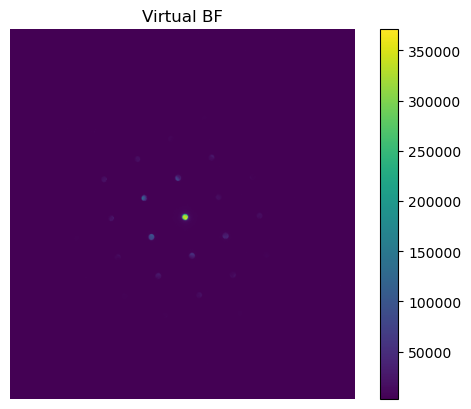

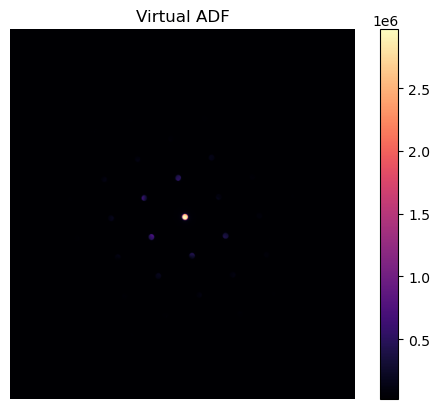

In [31]:
import numpy as np
import matplotlib.pyplot as plt

arr = arr_centered if "arr_centered" in globals() else np.asarray(dataset.data)

if arr.ndim != 4:
    raise RuntimeError(f"Expected a 4D array (scan_y, scan_x, q_y, q_x). Got shape {arr.shape}.")

Ny_scan, Nx_scan, Ny_dp, Nx_dp = arr.shape
cy, cx = (Ny_dp - 1) / 2.0, (Nx_dp - 1) / 2.0

y, x = np.ogrid[:Ny_dp, :Nx_dp]
r = np.sqrt((y - cy) ** 2 + (x - cx) ** 2)

rmax = min(cy, cx, Ny_dp - 1 - cy, Nx_dp - 1 - cx)

BF_INNER = 0.0
BF_OUTER = max(1.0, np.floor(0.35 * rmax))

ADF_INNER = max(BF_OUTER + 1.0, np.floor(0.55 * rmax))
ADF_OUTER = max(ADF_INNER + 1.0, np.floor(0.95 * rmax))

if BF_OUTER > rmax:
    BF_OUTER = np.floor(rmax)
if ADF_OUTER > rmax:
    ADF_OUTER = np.floor(rmax)
if ADF_INNER >= ADF_OUTER:
    ADF_INNER = max(0.0, ADF_OUTER - 1.0)

BF_mask = ((r >= BF_INNER) & (r <= BF_OUTER)).astype(np.float32)
ADF_mask = ((r >= ADF_INNER) & (r <= ADF_OUTER)).astype(np.float32)

BF_img = (arr * BF_mask[None, None, :, :]).sum(axis=(-2, -1))
ADF_img = (arr * ADF_mask[None, None, :, :]).sum(axis=(-2, -1))

print(f"DP shape: ({Ny_dp}, {Nx_dp})  rmax={rmax:.2f}")
print(f"BF radii:  {BF_INNER:.1f} → {BF_OUTER:.1f}")
print(f"ADF radii: {ADF_INNER:.1f} → {ADF_OUTER:.1f}")

plt.figure()
plt.imshow(BF_img, cmap="viridis")
plt.title("Virtual BF")
plt.colorbar()
plt.axis("off")

plt.figure()
plt.imshow(ADF_img, cmap="magma")
plt.title("Virtual ADF")
plt.colorbar()
plt.axis("off")

plt.show()

## Task 4: Basic 4D-STEM Visualization

Launch the interactive 4D-STEM browser using dataset.show() (if using a local GUI) or py4D.show_image().

Export a publication-quality figure of a virtual ADF image with a scale bar and a perceptually uniform colormap (e.g., magma).

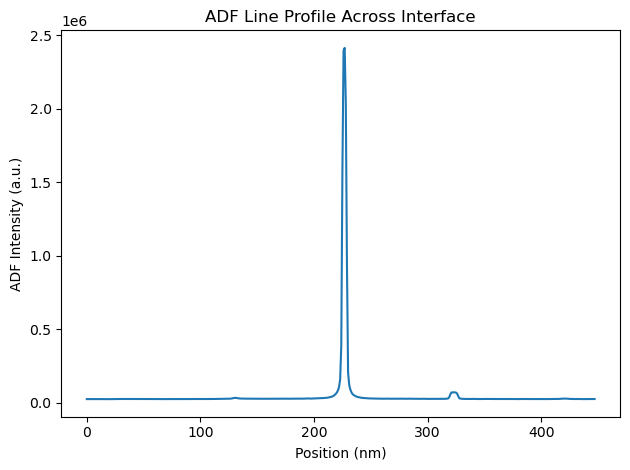

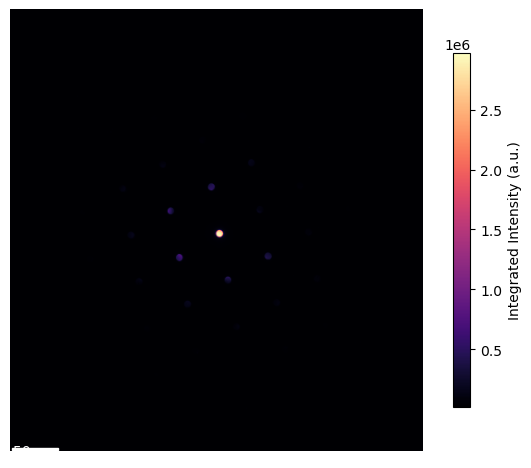

In [33]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle

scan_step_nm = 1.0
scale_bar_length = 50
scale_bar_pixels = int(scale_bar_length / scan_step_nm)

# -------------------------
# Line profile
# -------------------------
y0 = ADF_img.shape[0] // 2
profile = ADF_img[y0, :]
x_nm = np.arange(profile.size) * scan_step_nm

plt.figure()
plt.plot(x_nm, profile)
plt.xlabel("Position (nm)")
plt.ylabel("ADF Intensity (a.u.)")
plt.title("ADF Line Profile Across Interface")
plt.tight_layout()
plt.savefig("ADF_line_profile.png", dpi=300, bbox_inches="tight")
plt.show()


# -------------------------
# ADF image with scalebar
# -------------------------
fig, ax = plt.subplots()
im = ax.imshow(ADF_img, cmap="magma")
ax.axis("off")

if scale_bar_pixels < ADF_img.shape[1] - 5:
    bar_x, bar_y = 2, ADF_img.shape[0] - 4
    scale_bar = Rectangle((bar_x, bar_y), scale_bar_pixels, 2, color="white")
    ax.add_patch(scale_bar)
    ax.text(bar_x + scale_bar_pixels/2, bar_y - 4,
            f"{scale_bar_length} nm",
            color="white", ha="center", va="top", fontsize=10)

cbar = plt.colorbar(im, ax=ax, shrink=0.8)
cbar.set_label("Integrated Intensity (a.u.)")

plt.tight_layout()
plt.savefig("virtual_adf_figure_sisige.png", dpi=300, bbox_inches="tight")
plt.show()

## Task 5: Finalize and Submit

Update your README.md with a brief explanation of how virtual detectors allow post-acquisition imaging.

Push the completed Week 02 notebook to your GitHub repository.

Submit the repository link on Canvas.

In [34]:
import os
import json
import zipfile
from pathlib import Path

out_dir = Path("outputs")
out_dir.mkdir(exist_ok=True)

files_to_collect = [
    "virtual_adf_figure_sisige.png",
    "ADF_line_profile.png",
    "virtual_BF.png",
    "virtual_ADF.png",
    "ADF_virtual_magma.png",
    "ADF_virtual_magma.pdf",
]

existing = []
for f in files_to_collect:
    p = Path(f)
    if p.exists():
        dest = out_dir / p.name
        if p.resolve() != dest.resolve():
            dest.write_bytes(p.read_bytes())
        existing.append(str(dest))

readme_text = """# Week 02 Assignment — Virtual Detectors & Automated Diffraction Analysis

## What this notebook does
- Loads the Si/SiGe 4D-STEM dataset
- Applies CoM-based beam centering
- Builds virtual BF and ADF images by integrating user-defined regions of reciprocal space
- Saves publication-quality figures (with scale bar + colorbar) and a line profile across the interface

## What “re-playing the experiment” means
Because 4D-STEM stores a full diffraction pattern at every probe position, we can apply different *virtual detectors* after acquisition by changing the reciprocal-space mask (e.g., BF vs ADF annuli). This lets us re-create imaging modes, test detector geometries, and extract additional quantitative metrics (intensity, CoM, radial profiles) without re-collecting the experiment.

## Outputs
Figures are saved in `outputs/`.
"""
(out_dir / "README_Task5.md").write_text(readme_text)

summary = {
    "notes": "Task 5 packaging outputs + README snippet",
    "figures_saved": existing,
}
(out_dir / "task5_summary.json").write_text(json.dumps(summary, indent=2))

zip_path = Path("week02_submission_bundle.zip")
with zipfile.ZipFile(zip_path, "w", compression=zipfile.ZIP_DEFLATED) as z:
    for p in existing:
        z.write(p, arcname=p)
    z.write(out_dir / "README_Task5.md", arcname="README_Task5.md")
    z.write(out_dir / "task5_summary.json", arcname="task5_summary.json")

print("Saved outputs to:", out_dir.resolve())
print("Created zip:", zip_path.resolve())


Saved outputs to: /Users/jeremylee/Desktop/465/outputs
Created zip: /Users/jeremylee/Desktop/465/week02_submission_bundle.zip
